# Customer Lifetime Value (CLV) Prediction

This notebook demonstrates how to predict CLV using the Online Retail dataset.


In [1]:
import os

data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)
clv_data_path = os.path.join(data_dir, 'online_retail.csv')

if not os.path.exists(clv_data_path):
    print('Downloading Online Retail Dataset from Kaggle...')
    os.system(f'kaggle datasets download -d vijayuv/onlineretail -p {data_dir} --unzip')
    downloaded_file = os.path.join(data_dir, 'OnlineRetail.csv')
    if os.path.exists(downloaded_file):
        os.rename(downloaded_file, clv_data_path)
        print('Downloaded success.')
else:
    print('Dataset exists.')


Dataset exists.


## 2. Load and Preprocess Data


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv(clv_data_path, encoding='ISO-8859-1')
print(f'Loaded {len(df)} records.')

# Clean data
df = df[df['CustomerID'].notna()]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Aggregate by customer
customer_features = df.groupby('CustomerID').agg({
    'InvoiceNo': 'count',  # total_purchases
    'TotalPrice': ['sum', 'mean'],  # total_spend, avg_purchase_value
    'InvoiceDate': lambda x: (pd.to_datetime(x.max()) - pd.to_datetime(x.min())).days  # customer_age_days
}).reset_index()

customer_features.columns = ['CustomerID', 'total_purchases', 'total_spend', 'avg_purchase_value', 'customer_age_days']
customer_features['purchase_frequency'] = customer_features['total_purchases'] / (customer_features['customer_age_days'] + 1)

features = []
labels = []

for _, row in customer_features.iterrows():
    feature_vector = [
        float(row['total_purchases']),
        float(row['avg_purchase_value']),
        float(row['purchase_frequency']),
        float(row['customer_age_days']),
        0.7, 0, 0, 0.5  # Fillers for engagement, referrals, support, adoption from prod proxy
    ]
    features.append(feature_vector)
    labels.append(float(row['total_spend']))

features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
X = np.array(features)
y = np.array(labels)
print(f'Features shape: {X.shape}')


Loaded 541909 records.
Features shape: (4338, 8)


## 3. Train Model and Evaluate


Mean Absolute Error (MAE): $407.41
R^2 Score: 82.81%
Average CLV in Test Set: $2219.48


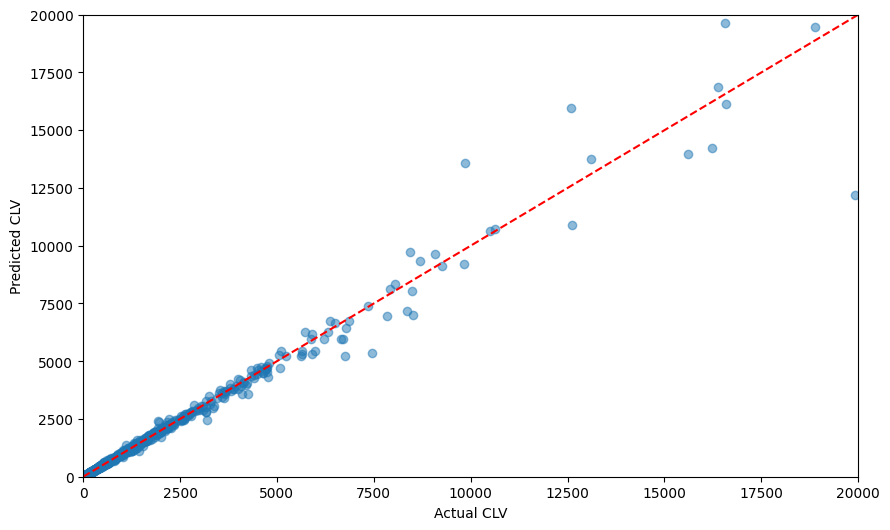

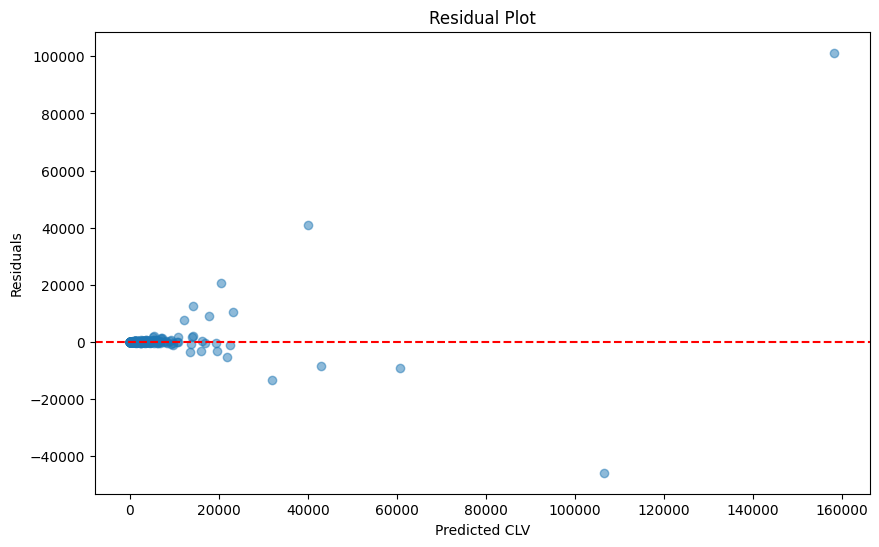

: 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
y_train_log = np.log1p(y_train)
model.fit(X_train_scaled, y_train_log)

y_pred_log = model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): ${mae:.2f}')
print(f'R^2 Score: {r2 * 100:.2f}%')
print(f'Average CLV in Test Set: ${np.mean(y_test):.2f}')

# Plot Actual vs Predicted
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')
plt.xlim(0, 20000)
plt.ylim(0, 20000)
plt.show()

# Plot Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted CLV')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()
